/tmp/ipykernel_3651/2281299511.py:41: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  palette = plt.cm.get_cmap("tab10", len(COUNTRIES))


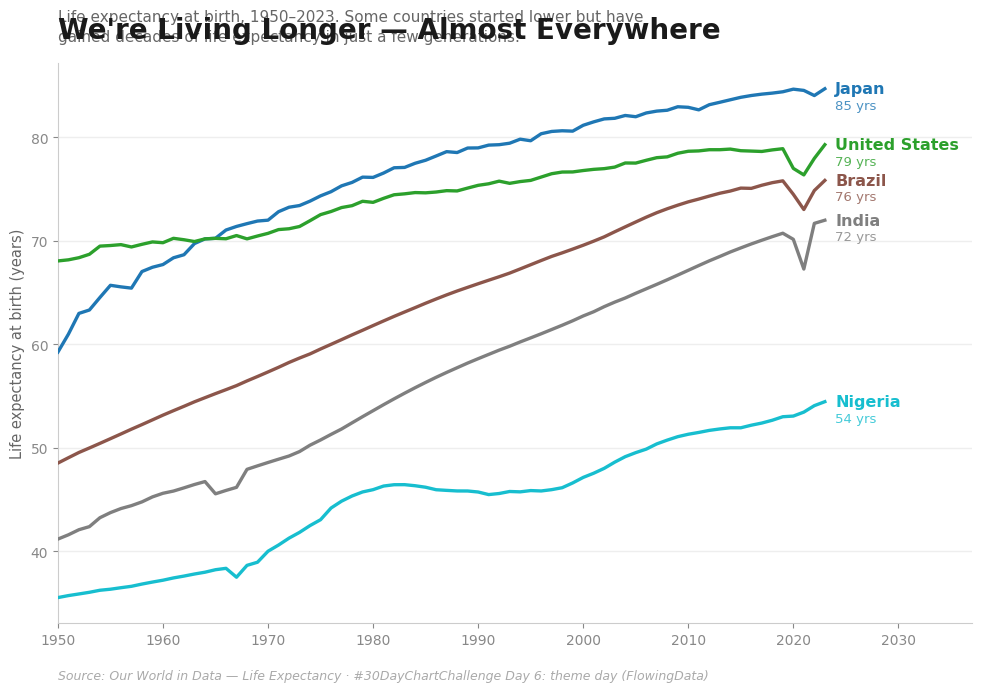

In [3]:
"""
#30DayChartChallenge — Day 6: theme day, FlowingData
"The Global Rise in Life Expectancy" — a clean, direct-labeled line chart
in the style popularized by FlowingData (Nathan Yau): minimal chrome, no
legend box, lines labeled right where they end, and a plain-language
title that does the explaining.

Data source (loaded live, no hardcoded values):
Our World in Data — Life expectancy (HMD/UN WPP combined series)
https://ourworldindata.org/life-expectancy
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------------------------------
# 1. CONFIG — change the country list or start year freely
# ---------------------------------------------------------------------------
COUNTRIES = ["Japan", "United States", "Brazil", "India", "Nigeria"]
YEAR_START = 1950

DATA_URL = "https://ourworldindata.org/grapher/life-expectancy-hmd-unwpp.csv?v=1&csvType=full&useColumnShortNames=false"

# ---------------------------------------------------------------------------
# 2. LOAD DATA DIRECTLY FROM SOURCE
# ---------------------------------------------------------------------------
df = pd.read_csv(DATA_URL, storage_options={"User-Agent": "Mozilla/5.0"})
value_col = [c for c in df.columns if c not in ("Entity", "Code", "Year")][0]
df = df.rename(columns={value_col: "life_expectancy"})

df = df[(df["Entity"].isin(COUNTRIES)) & (df["Year"] >= YEAR_START)].copy()
latest_year = int(df["Year"].max())

# ---------------------------------------------------------------------------
# 3. PLOT — clean, directly-labeled line chart (no legend box)
# ---------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 7), facecolor="#FFFFFF")
ax.set_facecolor("#FFFFFF")

palette = plt.cm.get_cmap("tab10", len(COUNTRIES))

for i, country in enumerate(COUNTRIES):
    sub = df[df["Entity"] == country].sort_values("Year")
    if sub.empty:
        print(f"Skipping {country}: no data found")
        continue
    color = palette(i)
    ax.plot(sub["Year"], sub["life_expectancy"], color=color, linewidth=2.4, zorder=3)

    last_year = sub["Year"].iloc[-1]
    last_val = sub["life_expectancy"].iloc[-1]
    ax.text(
        last_year + 1, last_val, f"{country}",
        fontsize=11.5, fontweight="bold", color=color, va="center",
    )
    ax.text(
        last_year + 1, last_val - 1.6, f"{last_val:.0f} yrs",
        fontsize=9.5, color=color, va="center", alpha=0.8,
    )

# Minimal chrome: no top/right spines, light horizontal gridlines only
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color("#cccccc")
ax.yaxis.grid(True, color="#eeeeee", linewidth=1, zorder=0)
ax.set_axisbelow(True)
ax.tick_params(colors="#888888", labelsize=10)

ax.set_xlim(YEAR_START, latest_year + 14)
ax.set_xlabel("")
ax.set_ylabel("Life expectancy at birth (years)", fontsize=10.5, color="#666666")

ax.set_title(
    "We're Living Longer — Almost Everywhere",
    fontsize=20, fontweight="bold", color="#1a1a1a", loc="left", pad=18,
)
ax.text(
    0, 1.04,
    f"Life expectancy at birth, {YEAR_START}–{latest_year}. Some countries started lower but have\n"
    "gained decades of life expectancy in just a few generations.",
    fontsize=11, color="#666666", ha="left", transform=ax.transAxes, linespacing=1.4,
)
ax.text(
    0, -0.1,
    "Source: Our World in Data — Life Expectancy · #30DayChartChallenge Day 6: theme day (FlowingData)",
    fontsize=9, color="#aaaaaa", ha="left", transform=ax.transAxes, style="italic",
)

plt.tight_layout()
plt.savefig("day6_flowingdata.png", dpi=200, facecolor="#FFFFFF", bbox_inches="tight")
plt.show()